In [6]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  

### Load Ensemble JSON files

The following result files were generated from the corresponding notebooks:

- `01_ensemble.json` → `../notebooks/01_leyla.louache.ipynb`
- `02_ensemble.json` → `../notebooks/02_Tetic-Seiwerth.Lucas.ipynb`
- `03_ensemble.json` → `../notebooks/03_Ghadiri.Seyedeh.Sara.ipynb`

In [3]:
RESULTS_DIR = "../results"
files_to_compare = ["01_ensemble.json", "02_ensemble.json", "03_ensemble.json"]

rows = []

for file in files_to_compare:
    path = os.path.join(RESULTS_DIR, file)
    
    with open(path, "r") as f:
        data = json.load(f)

    for category, result in data.items():

        # keep only Simple Stacking from 01_ensemble
        if file == "01_ensemble.json" and category != "Simple Stacking":
            continue

        row = {
            "source_file": file,
            "category": result.get("category", category),
            "model_name": result.get("model_name", None),

            "train_accuracy": result["validation_experiment"]["train_metrics"]["accuracy"],
            "val_accuracy": result["validation_experiment"]["validation_metrics"]["accuracy"],
            "train_f1": result["validation_experiment"]["train_metrics"]["f1_macro"],
            "val_f1": result["validation_experiment"]["validation_metrics"]["f1_macro"],

            "train_final_accuracy": result["final_test_experiment"]["train_plus_validation_metrics"]["accuracy"],
            "test_accuracy": result["final_test_experiment"]["test_metrics"]["accuracy"],
            "train_final_f1": result["final_test_experiment"]["train_plus_validation_metrics"]["f1_macro"],
            "test_f1": result["final_test_experiment"]["test_metrics"]["f1_macro"],
        }

        rows.append(row)

df = pd.DataFrame(rows)

display(
    df[["source_file", "category", "model_name"]]
    .sort_values(by="source_file")
)

,source_file,category,model_name
0,01_ensemble.json,Simple Stacking,StackingClassifier
1,02_ensemble.json,Stacking Ensemble,StackingClassifier
2,03_ensemble.json,Voting Ensemble,VotingClassifier


### Load CNN JSON file

- `01_robustness.json` → `../notebooks/01_leyla.louache.ipynb`

In [28]:
with open("../results/01_robustness.json", "r") as f:
    robustness_results = json.load(f)

In [29]:
robustness_df = pd.DataFrame(robustness_results)

robustness_df.head()

,model,accuracy,f1_weighted
0,simple_stacking_model_clean,0.9741,0.974070
1,advanced_stacking_model_clean,0.9836,0.983592
2,model_simple.keras_clean,0.9851,0.985085
3,model_drop.keras_clean,0.9906,0.990601
4,model_drop_move.keras_clean,0.9860,0.986001


Take only 2CNN models that were trained on clean dataset:

In [32]:
clean_cnn_selected = robustness_df[
    robustness_df["model"].isin([
        "model_simple.keras_clean",
        "model_drop.keras_clean"
    ])
][["model", "accuracy", "f1_weighted"]]

clean_cnn_selected

,model,accuracy,f1_weighted
2,model_simple.keras_clean,0.9851,0.985085
3,model_drop.keras_clean,0.9906,0.990601


## Plot

__Accuracy Test vs F1 score__: (3 best ensemble models)

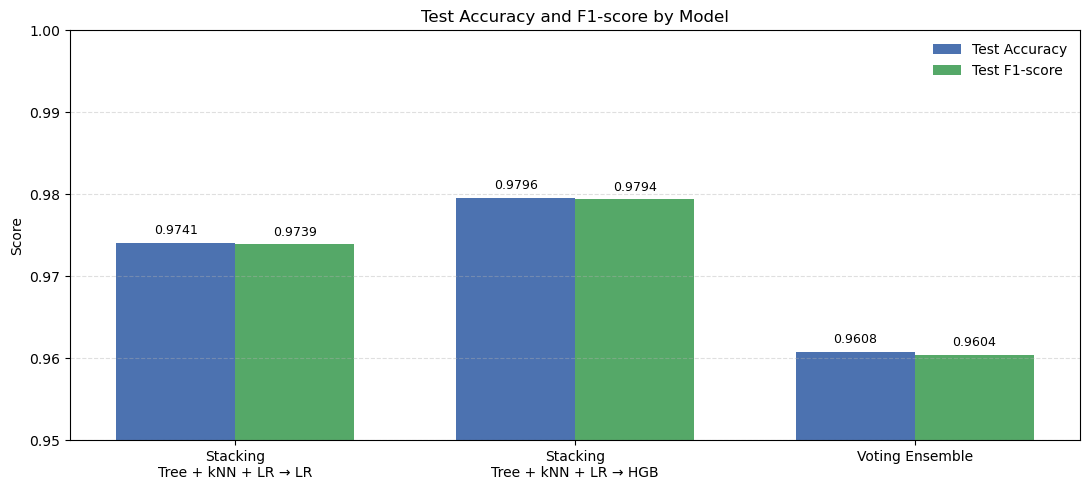

In [24]:
model_labels = []
test_accuracies = []
test_f1_scores = []

for _, row in df.iterrows():

    if row["source_file"] == "01_ensemble.json":
        label = "Stacking\nTree + kNN + LR → LR"

    elif row["source_file"] == "02_ensemble.json":
        label = "Stacking\nTree + kNN + LR → HGB"

    elif row["source_file"] == "03_ensemble.json":
        label = row["category"]

    else:
        label = row["category"]

    model_labels.append(label)
    test_accuracies.append(row["test_accuracy"])
    test_f1_scores.append(row["test_f1"])


x = np.arange(len(model_labels))
width = 0.35

plt.figure(figsize=(11,5))

bars1 = plt.bar(
    x - width/2,
    test_accuracies,
    width,
    label="Test Accuracy",
    color="#4C72B0"
)

bars2 = plt.bar(
    x + width/2,
    test_f1_scores,
    width,
    label="Test F1-score",
    color="#55A868"
)

plt.xticks(x, model_labels, rotation=0, ha="center")
plt.ylabel("Score")
plt.title("Test Accuracy and F1-score by Model")

plt.ylim(0.95, 1.0)

plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(frameon=False)

# add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height:.4f}",
        ha="center",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height:.4f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "../plot/test_accuracy_vs_f1_per_model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

__Test Accuracy__: (across all models)

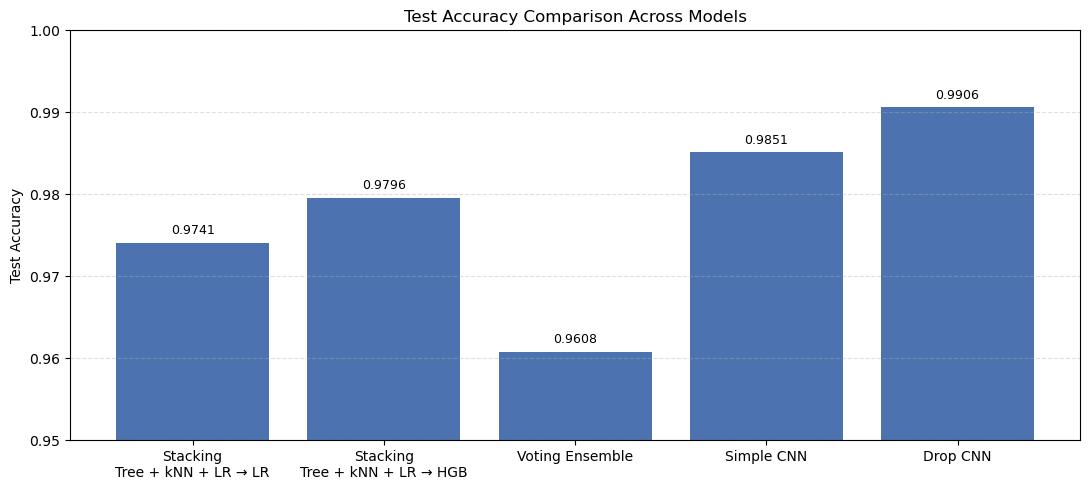

In [33]:
model_labels = []
test_accuracies = []

for _, row in df.iterrows():

    if row["source_file"] == "01_ensemble.json":
        label = "Stacking\nTree + kNN + LR → LR"

    elif row["source_file"] == "02_ensemble.json":
        label = "Stacking\nTree + kNN + LR → HGB"

    elif row["source_file"] == "03_ensemble.json":
        label = row["category"]

    else:
        label = row["category"]

    model_labels.append(label)
    test_accuracies.append(row["test_accuracy"])

label_map = {
    "model_simple.keras_clean": "Simple CNN",
    "model_drop.keras_clean": "Drop CNN"
}

for _, row in clean_cnn_selected.iterrows():
    model_labels.append(label_map.get(row["model"], row["model"]))
    test_accuracies.append(row["accuracy"])

x = np.arange(len(model_labels))

plt.figure(figsize=(11,5))

bars = plt.bar(
    x,
    test_accuracies,
    color="#4C72B0"
)

plt.xticks(x, model_labels, rotation=0, ha="center")

plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison Across Models")

plt.ylim(0.95, 1.0)

plt.grid(axis="y", linestyle="--", alpha=0.4)

# add value labels
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h + 0.001,
        f"{h:.4f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "../plot/test_accuracy_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Summary

From the best to the worst test accuracy:

In [12]:
summary = df[[
    "source_file",
    "category",
    "val_accuracy",
    "test_accuracy",
    "val_f1",
    "test_f1"
]].sort_values(by="test_accuracy", ascending=False)

display(summary)

,source_file,category,val_accuracy,test_accuracy,val_f1,test_f1
1,02_ensemble.json,Stacking Ensemble,0.977333,0.9796,0.977215,0.979448
0,01_ensemble.json,Simple Stacking,0.975500,0.9741,0.975480,0.973915
2,03_ensemble.json,Voting Ensemble,0.959000,0.9608,0.958726,0.960421


In [39]:
summary_clean = summary[[
    "source_file",
    "category",
    "test_accuracy",
    "test_f1"
]]

clean_cnn_selected_formatted = clean_cnn_selected.copy()

clean_cnn_selected_formatted["source_file"] = "01_robustness.json"
clean_cnn_selected_formatted["category"] = clean_cnn_selected_formatted["model"]
clean_cnn_selected_formatted["test_accuracy"] = clean_cnn_selected_formatted["accuracy"]
clean_cnn_selected_formatted["test_f1"] = clean_cnn_selected_formatted["f1_weighted"]

clean_cnn_selected_formatted = clean_cnn_selected_formatted[[
    "source_file",
    "category",
    "test_accuracy",
    "test_f1"
]]

final_summary = pd.concat([summary_clean, clean_cnn_selected_formatted], ignore_index=True)
final_summary = final_summary.sort_values(by="test_accuracy", ascending=False)
display(final_summary)


,source_file,category,test_accuracy,test_f1
4,01_robustness.json,model_drop.keras_clean,0.9906,0.990601
3,01_robustness.json,model_simple.keras_clean,0.9851,0.985085
0,02_ensemble.json,Stacking Ensemble,0.9796,0.979448
1,01_ensemble.json,Simple Stacking,0.9741,0.973915
2,03_ensemble.json,Voting Ensemble,0.9608,0.960421
